#### Notebook Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255/voice-command-assistant")


for p in [
    PROJECT_ROOT/"notebooks",
    PROJECT_ROOT/"src",
    PROJECT_ROOT/"data/raw",
    PROJECT_ROOT/"data/processed",
    PROJECT_ROOT/"data/cache",
    PROJECT_ROOT/"models",
    PROJECT_ROOT/"results/figures",
    PROJECT_ROOT/"results/logs",
    PROJECT_ROOT/"reports",
]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(PROJECT_ROOT/"data/cache/hf_home")
os.environ["HF_DATASETS_CACHE"] = str(PROJECT_ROOT/"data/cache/hf_datasets")
os.environ["TRANSFORMERS_CACHE"] = str(PROJECT_ROOT/"data/cache/transformers")


print("PROJECT_ROOT:", PROJECT_ROOT)
print("HF_HOME:", os.environ["HF_HOME"])

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/DAT255/voice-command-assistant
HF_HOME: /content/drive/MyDrive/DAT255/voice-command-assistant/data/cache/hf_home


# 03 — Baseline CNN training (from scratch)

This notebook trains at least one model from scratch on Speech Commands.

Plan:
1) 4-class baseline: up/down/left/right
2) 5-class realistic: up/down/left/right/unknown (handle imbalance)

We log experiments and evaluate objectively (accuracy + macro F1 + confusion matrix).

## 1 .Setup + DataLoaders (4-class) + CNN model

#### Imports + device + seeds

In [2]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import librosa
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device: cuda


#### Load index + HF dataset + build fast lookup

In [3]:
index_df = pd.read_csv(PROJECT_ROOT/"data/processed/index.csv")

ds = load_dataset("google/speech_commands", "v0.02")
print(ds)

file_to_idx = {}
for split in ["train", "validation", "test"]:
    files = ds[split]["file"]
    file_to_idx[split] = {f: i for i, f in enumerate(files)}

def fast_find_by_file(split, file_path):
    i = file_to_idx[split].get(file_path, None)
    if i is None:
        raise KeyError(f"File not found in split={split}: {file_path}")
    return ds[split][i]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using the latest cached version of the dataset since google/speech_commands couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'v0.02' at /content/drive/MyDrive/DAT255/voice-command-assistant/data/cache/hf_datasets/google___speech_commands/v0.02/0.2.0/ba3d9a6cf49aa1313c51abe16b59203451482ccb9fee6d23c94fecabf3e206da (last modified on Wed Feb 25 14:03:30 2026).


DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 84848
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 9982
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 4890
    })
})


#### Preprocessing config + dataset class (mel-spectrogram)

In [4]:
SR = 16000
N_SAMPLES = 16000

N_MELS = 64
HOP_LENGTH = 160
N_FFT = 400

FOUR_CLASS = {"up", "down", "left", "right"}

def pad_or_trim(x: np.ndarray, n_samples: int = N_SAMPLES) -> np.ndarray:
    if len(x) < n_samples:
        x = np.pad(x, (0, n_samples - len(x)), mode="constant")
    else:
        x = x[:n_samples]
    return x.astype(np.float32)

class SpeechCommandsMelDataset(Dataset):
    def __init__(self, index_df, split="train", allowed_targets=None):
        df = index_df[index_df["split"] == split]
        if allowed_targets is not None:
            df = df[df["target_label"].isin(allowed_targets)]
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = row["file"]
        target_id = int(row["target_id"])

        ex = fast_find_by_file(row["split"], file_path)
        wave = pad_or_trim(ex["audio"]["array"])

        S = librosa.feature.melspectrogram(
            y=wave, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
            n_mels=N_MELS, fmax=SR/2
        )
        S_db = librosa.power_to_db(S, ref=np.max)

        X = torch.tensor(S_db).unsqueeze(0).float()
        y = torch.tensor(target_id).long()
        return X, y

#### Build 4-class dataloaders

In [5]:
label_to_4id = {"up": 0, "down": 1, "left": 2, "right": 3}

class FourClassWrapper(Dataset):
    def __init__(self, base_ds, base_df):
        self.base_ds = base_ds
        self.df = base_df.reset_index(drop=True)

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        X, _ = self.base_ds[idx]
        lbl = self.df.iloc[idx]["target_label"]
        y4 = torch.tensor(label_to_4id[lbl]).long()
        return X, y4

base_train = SpeechCommandsMelDataset(index_df, split="train", allowed_targets=FOUR_CLASS)
base_val   = SpeechCommandsMelDataset(index_df, split="validation", allowed_targets=FOUR_CLASS)
base_test  = SpeechCommandsMelDataset(index_df, split="test", allowed_targets=FOUR_CLASS)

df_train = index_df[(index_df["split"]=="train") & (index_df["target_label"].isin(FOUR_CLASS))].reset_index(drop=True)
df_val   = index_df[(index_df["split"]=="validation") & (index_df["target_label"].isin(FOUR_CLASS))].reset_index(drop=True)
df_test  = index_df[(index_df["split"]=="test") & (index_df["target_label"].isin(FOUR_CLASS))].reset_index(drop=True)

train_ds = FourClassWrapper(base_train, df_train)
val_ds   = FourClassWrapper(base_val, df_val)
test_ds  = FourClassWrapper(base_test, df_test)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("Batch shapes:", xb.shape, yb.shape)
print("Unique labels in batch:", sorted(set(yb.tolist())))

Batch shapes: torch.Size([64, 1, 64, 101]) torch.Size([64])
Unique labels in batch: [0, 1, 2, 3]


#### Define small CNN (from scratch)

In [6]:
class SmallSpectrogramCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

model = SmallSpectrogramCNN(n_classes=4).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", n_params)

SmallSpectrogramCNN(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=64, out_features=4, bias=True)
  )
)
Trainable params: 23780


## 2. Training setup (loss/optimizer) + TensorBoard logging

#### imports + run config + TensorBoard writer

In [7]:
import time
from dataclasses import dataclass
from torch.utils.tensorboard import SummaryWriter

@dataclass
class TrainConfig:
    run_name: str = "cnn_4class_baseline"
    epochs: int = 10
    lr: float = 1e-3
    weight_decay: float = 1e-4
    log_every_steps: int = 50

cfg = TrainConfig(
    run_name=f"cnn_4class_baseline_{int(time.time())}",
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

log_dir = PROJECT_ROOT / "results" / "logs" / cfg.run_name
log_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(log_dir))

print("Run:", cfg.run_name)
print("TensorBoard logdir:", log_dir)

Run: cnn_4class_baseline_1772452765
TensorBoard logdir: /content/drive/MyDrive/DAT255/voice-command-assistant/results/logs/cnn_4class_baseline_1772452765


#### loss/optimizer + train/eval functions

In [8]:
import torch
import torch.nn.functional as F

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def run_eval(model, loader):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    all_preds = []
    all_targets = []

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

        all_preds.append(torch.argmax(logits, dim=1).cpu())
        all_targets.append(y.cpu())

    avg_loss = total_loss / max(1, n_batches)
    avg_acc = total_acc / max(1, n_batches)

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return avg_loss, avg_acc, all_targets, all_preds

def run_train_epoch(model, loader, epoch_idx):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    start = time.time()

    for step, (X, y) in enumerate(loader):
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

        if (step + 1) % cfg.log_every_steps == 0:
            writer.add_scalar("train/loss_step", loss.item(), epoch_idx * len(loader) + step)
            writer.add_scalar("train/acc_step", accuracy_from_logits(logits, y), epoch_idx * len(loader) + step)

    dt = time.time() - start
    avg_loss = total_loss / max(1, n_batches)
    avg_acc = total_acc / max(1, n_batches)
    return avg_loss, avg_acc, dt

#### training loop + save “best” checkpoint

In [9]:
best_val_acc = -1.0
best_path = PROJECT_ROOT / "models" / f"{cfg.run_name}_best.pt"

for epoch in range(cfg.epochs):
    train_loss, train_acc, train_time = run_train_epoch(model, train_loader, epoch)
    val_loss, val_acc, y_true, y_pred = run_eval(model, val_loader)

    print(f"Epoch {epoch+1:02d}/{cfg.epochs} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"time {train_time:.1f}s")

    writer.add_scalar("train/loss", train_loss, epoch)
    writer.add_scalar("train/acc", train_acc, epoch)
    writer.add_scalar("val/loss", val_loss, epoch)
    writer.add_scalar("val/acc", val_acc, epoch)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "cfg": cfg.__dict__,
            "epoch": epoch,
            "val_acc": val_acc,
        }, best_path)
        print("✅ Saved best checkpoint to:", best_path)

writer.flush()
print("Best val acc:", best_val_acc)

Epoch 01/10 | train loss 1.1540 acc 0.5503 | val loss 1.0705 acc 0.5115 | time 55.9s
✅ Saved best checkpoint to: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_4class_baseline_1772452765_best.pt
Epoch 02/10 | train loss 0.8175 acc 0.7400 | val loss 0.6528 acc 0.8059 | time 51.9s
✅ Saved best checkpoint to: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_4class_baseline_1772452765_best.pt
Epoch 03/10 | train loss 0.5777 acc 0.8306 | val loss 0.5095 acc 0.8356 | time 51.9s
✅ Saved best checkpoint to: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_4class_baseline_1772452765_best.pt
Epoch 04/10 | train loss 0.4476 acc 0.8655 | val loss 0.4600 acc 0.8480 | time 43.1s
✅ Saved best checkpoint to: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_4class_baseline_1772452765_best.pt
Epoch 05/10 | train loss 0.3792 acc 0.8865 | val loss 0.5680 acc 0.7955 | time 42.6s
Epoch 06/10 | train loss 0.3273 acc 0.8965 | val loss 0.6576 ac

## 3. Objective evaluation (accuracy + macro F1 + confusion matrix)

#### Load best checkpoint

In [10]:
best_ckpt_path = PROJECT_ROOT/"models"/f"{cfg.run_name}_best.pt"

ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

print("Loaded checkpoint:", best_ckpt_path)
print("Saved epoch:", ckpt.get("epoch"))
print("Saved val_acc:", ckpt.get("val_acc"))

Loaded checkpoint: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_4class_baseline_1772452765_best.pt
Saved epoch: 3
Saved val_acc: 0.8479859336562778


#### Helper functions: confusion matrix + macro F1

In [11]:
import numpy as np
import matplotlib.pyplot as plt

class_names_4 = ["up", "down", "left", "right"]

def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def macro_f1_from_cm(cm):
    f1s = []
    for k in range(cm.shape[0]):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        f1s.append(f1)

    return float(np.mean(f1s)), np.array(f1s)

def plot_and_save_cm(cm, class_names, title, save_path):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved:", save_path)

#### Evaluate on validation

Validation accuracy: 0.8479859336562778
Validation macro F1: 0.8443385102824946
Per-class F1: {'up': np.float64(0.8792), 'down': np.float64(0.8684), 'left': np.float64(0.8017), 'right': np.float64(0.828)}


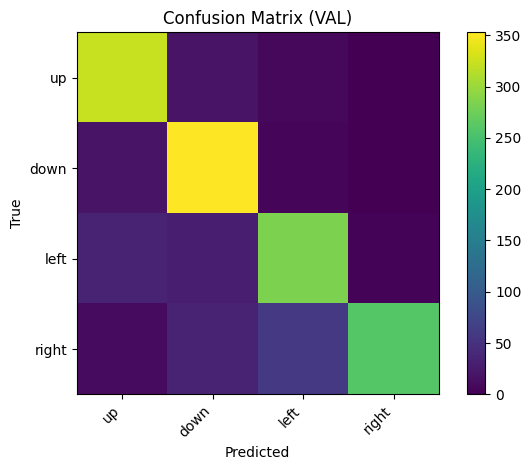

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/cnn_4class_baseline_1772452765_cm_val.png


In [12]:
val_loss, val_acc, y_true_val, y_pred_val = run_eval(model, val_loader)

cm_val = confusion_matrix_np(y_true_val, y_pred_val, n_classes=4)
macro_f1_val, per_class_f1_val = macro_f1_from_cm(cm_val)

print("Validation accuracy:", val_acc)
print("Validation macro F1:", macro_f1_val)
print("Per-class F1:", dict(zip(class_names_4, per_class_f1_val.round(4))))

val_cm_path = PROJECT_ROOT/"results/figures"/f"{cfg.run_name}_cm_val.png"
plot_and_save_cm(cm_val, class_names_4, "Confusion Matrix (VAL)", val_cm_path)

#### Evaluate on test set

Test accuracy: 0.8390347636662997
Test macro F1: 0.8344727371258059
Test per-class F1: {'up': np.float64(0.907), 'down': np.float64(0.8506), 'left': np.float64(0.8134), 'right': np.float64(0.7669)}


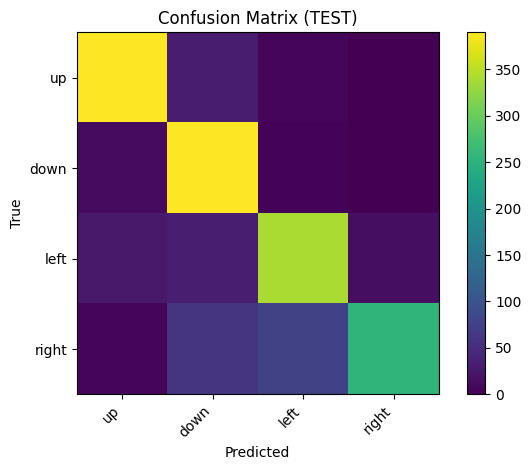

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/cnn_4class_baseline_1772452765_cm_test.png


In [13]:
test_loss, test_acc, y_true_test, y_pred_test = run_eval(model, test_loader)

cm_test = confusion_matrix_np(y_true_test, y_pred_test, n_classes=4)
macro_f1_test, per_class_f1_test = macro_f1_from_cm(cm_test)

print("Test accuracy:", test_acc)
print("Test macro F1:", macro_f1_test)
print("Test per-class F1:", dict(zip(class_names_4, per_class_f1_test.round(4))))

test_cm_path = PROJECT_ROOT/"results/figures"/f"{cfg.run_name}_cm_test.png"
plot_and_save_cm(cm_test, class_names_4, "Confusion Matrix (TEST)", test_cm_path)

#### Save metrics to CSV

In [14]:
metrics_dir = PROJECT_ROOT/"results/metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

metrics = {
    "run_name": cfg.run_name,
    "n_params": int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
    "best_val_acc": float(ckpt.get("val_acc")),
    "val_acc": float(val_acc),
    "val_macro_f1": float(macro_f1_val),
    "test_acc": float(test_acc),
    "test_macro_f1": float(macro_f1_test),
}

metrics_path = metrics_dir/f"{cfg.run_name}_metrics.csv"
pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

print("Saved metrics:", metrics_path)
pd.DataFrame([metrics])

Saved metrics: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/cnn_4class_baseline_1772452765_metrics.csv


,run_name,n_params,best_val_acc,val_acc,val_macro_f1,test_acc,test_macro_f1
0,cnn_4class_baseline_1772452765,23780,0.847986,0.847986,0.844339,0.839035,0.834473


## 4. 5-class training (up/down/left/right/unknown) with imbalance handling

#### Build 5-class datasets/dataloaders

In [15]:
FIVE_CLASS = {"up", "down", "left", "right", "unknown"}
label_to_5id = {"up": 0, "down": 1, "left": 2, "right": 3, "unknown": 4}
class_names_5 = ["up", "down", "left", "right", "unknown"]

base5_train = SpeechCommandsMelDataset(index_df, split="train", allowed_targets=FIVE_CLASS)
base5_val   = SpeechCommandsMelDataset(index_df, split="validation", allowed_targets=FIVE_CLASS)
base5_test  = SpeechCommandsMelDataset(index_df, split="test", allowed_targets=FIVE_CLASS)

df5_train = index_df[(index_df["split"]=="train") & (index_df["target_label"].isin(FIVE_CLASS))].reset_index(drop=True)
df5_val   = index_df[(index_df["split"]=="validation") & (index_df["target_label"].isin(FIVE_CLASS))].reset_index(drop=True)
df5_test  = index_df[(index_df["split"]=="test") & (index_df["target_label"].isin(FIVE_CLASS))].reset_index(drop=True)

class FiveClassWrapper(Dataset):
    def __init__(self, base_ds, base_df):
        self.base_ds = base_ds
        self.df = base_df.reset_index(drop=True)
    def __len__(self):
        return len(self.base_ds)
    def __getitem__(self, idx):
        X, _ = self.base_ds[idx]
        lbl = self.df.iloc[idx]["target_label"]
        y5 = torch.tensor(label_to_5id[lbl]).long()
        return X, y5

train5_ds = FiveClassWrapper(base5_train, df5_train)
val5_ds   = FiveClassWrapper(base5_val, df5_val)
test5_ds  = FiveClassWrapper(base5_test, df5_test)

train5_loader = DataLoader(train5_ds, batch_size=64, shuffle=True, num_workers=2)
val5_loader   = DataLoader(val5_ds, batch_size=64, shuffle=False, num_workers=2)
test5_loader  = DataLoader(test5_ds, batch_size=64, shuffle=False, num_workers=2)

xb, yb = next(iter(train5_loader))
print("5-class batch:", xb.shape, yb.shape, "unique labels:", sorted(set(yb.tolist())))

5-class batch: torch.Size([64, 1, 64, 101]) torch.Size([64]) unique labels: [0, 1, 2, 3, 4]


#### Compute class weights from train split

In [16]:
train_counts = df5_train["target_label"].value_counts()
print("Train counts:\n", train_counts)

counts = np.array([train_counts.get(c, 0) for c in class_names_5], dtype=np.float32)
weights = counts.sum() / np.maximum(counts, 1.0)
weights = weights / weights.mean()

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(class_names_5, weights.round(3))))

Train counts:
 target_label
unknown    72710
down        3134
left        3037
right       3019
up          2948
Name: count, dtype: int64
Class weights: {'up': np.float32(1.273), 'down': np.float32(1.197), 'left': np.float32(1.235), 'right': np.float32(1.243), 'unknown': np.float32(0.052)}


#### New model (from scratch) + new train config

In [17]:
model5 = SmallSpectrogramCNN(n_classes=5).to(device)

cfg5 = TrainConfig(
    run_name=f"cnn_5class_weighted_{int(time.time())}",
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

log_dir5 = PROJECT_ROOT / "results" / "logs" / cfg5.run_name
log_dir5.mkdir(parents=True, exist_ok=True)
writer5 = SummaryWriter(log_dir=str(log_dir5))

criterion5 = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer5 = torch.optim.Adam(model5.parameters(), lr=cfg5.lr, weight_decay=cfg5.weight_decay)

print("Run:", cfg5.run_name)
print("TensorBoard logdir:", log_dir5)

Run: cnn_5class_weighted_1772453499
TensorBoard logdir: /content/drive/MyDrive/DAT255/voice-command-assistant/results/logs/cnn_5class_weighted_1772453499


#### Train/eval functions (reuse, but with model5 + criterion5 + optimizer5)

In [18]:
def acc_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def eval5(model, loader):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    all_preds, all_targets = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = criterion5(logits, y)
        total_loss += loss.item()
        total_acc += acc_logits(logits, y)
        n += 1
        all_preds.append(torch.argmax(logits, dim=1).cpu())
        all_targets.append(y.cpu())
    return total_loss/max(n,1), total_acc/max(n,1), torch.cat(all_targets).numpy(), torch.cat(all_preds).numpy()

def train_epoch5(model, loader, epoch_idx):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    start = time.time()
    for step, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        optimizer5.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion5(logits, y)
        loss.backward()
        optimizer5.step()
        total_loss += loss.item()
        total_acc += acc_logits(logits, y)
        n += 1
        if (step+1) % cfg5.log_every_steps == 0:
            writer5.add_scalar("train/loss_step", loss.item(), epoch_idx * len(loader) + step)
            writer5.add_scalar("train/acc_step", acc_logits(logits, y), epoch_idx * len(loader) + step)
    return total_loss/max(n,1), total_acc/max(n,1), time.time()-start

#### Training loop + save best checkpoint

In [19]:
best_val_acc5 = -1.0
best_path5 = PROJECT_ROOT/"models"/f"{cfg5.run_name}_best.pt"

for epoch in range(cfg5.epochs):
    tr_loss, tr_acc, tr_time = train_epoch5(model5, train5_loader, epoch)
    va_loss, va_acc, yv, pv = eval5(model5, val5_loader)

    print(f"Epoch {epoch+1:02d}/{cfg5.epochs} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"time {tr_time:.1f}s")

    writer5.add_scalar("train/loss", tr_loss, epoch)
    writer5.add_scalar("train/acc", tr_acc, epoch)
    writer5.add_scalar("val/loss", va_loss, epoch)
    writer5.add_scalar("val/acc", va_acc, epoch)

    if va_acc > best_val_acc5:
        best_val_acc5 = va_acc
        torch.save({
            "model_state_dict": model5.state_dict(),
            "cfg": cfg5.__dict__,
            "epoch": epoch,
            "val_acc": va_acc,
        }, best_path5)
        print("✅ Saved best checkpoint:", best_path5)

writer5.flush()
print("Best val acc (5-class):", best_val_acc5)

Epoch 01/10 | train loss 1.1828 acc 0.3647 | val loss 1.2249 acc 0.4166 | time 384.7s
✅ Saved best checkpoint: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_5class_weighted_1772453499_best.pt
Epoch 02/10 | train loss 0.6722 acc 0.5885 | val loss 0.4331 acc 0.8643 | time 353.6s
✅ Saved best checkpoint: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_5class_weighted_1772453499_best.pt
Epoch 03/10 | train loss 0.5303 acc 0.6614 | val loss 0.8589 acc 0.5948 | time 329.4s
Epoch 04/10 | train loss 0.4673 acc 0.6942 | val loss 0.7482 acc 0.6726 | time 353.1s
Epoch 05/10 | train loss 0.4183 acc 0.7207 | val loss 0.3310 acc 0.8910 | time 340.9s
✅ Saved best checkpoint: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_5class_weighted_1772453499_best.pt
Epoch 06/10 | train loss 0.3905 acc 0.7380 | val loss 1.2366 acc 0.4992 | time 344.5s
Epoch 07/10 | train loss 0.3742 acc 0.7503 | val loss 0.5922 acc 0.7605 | time 345.8s
Epoch 08/10 | train los

## 5. Objective evaluation (5-class): accuracy + macro F1 + confusion matrix

#### Load best 5-class checkpoint

In [20]:
best_ckpt5_path = PROJECT_ROOT/"models"/f"{cfg5.run_name}_best.pt"

ckpt5 = torch.load(best_ckpt5_path, map_location=device)
model5.load_state_dict(ckpt5["model_state_dict"])
model5.to(device)
model5.eval()

print("Loaded checkpoint:", best_ckpt5_path)
print("Saved epoch:", ckpt5.get("epoch"))
print("Saved val_acc:", ckpt5.get("val_acc"))

Loaded checkpoint: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_5class_weighted_1772453499_best.pt
Saved epoch: 4
Saved val_acc: 0.8910191788887366


#### Eval 5-class on validation + save confusion matrix

VAL (5-class) accuracy: 0.8910191788887366
VAL (5-class) macro F1: 0.6735654187029281
VAL per-class F1: {'up': np.float64(0.5793), 'down': np.float64(0.587), 'left': np.float64(0.6336), 'right': np.float64(0.6279), 'unknown': np.float64(0.9399)}


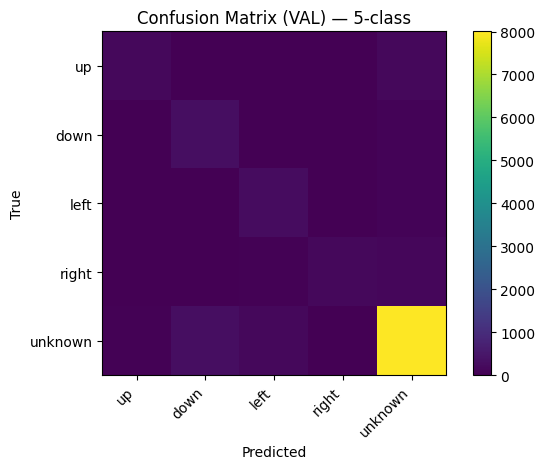

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/cnn_5class_weighted_1772453499_cm_val.png


In [21]:
val5_loss, val5_acc, y_true_val5, y_pred_val5 = eval5(model5, val5_loader)

cm_val5 = confusion_matrix_np(y_true_val5, y_pred_val5, n_classes=5)
macro_f1_val5, per_class_f1_val5 = macro_f1_from_cm(cm_val5)

print("VAL (5-class) accuracy:", val5_acc)
print("VAL (5-class) macro F1:", macro_f1_val5)
print("VAL per-class F1:", dict(zip(class_names_5, per_class_f1_val5.round(4))))

val5_cm_path = PROJECT_ROOT/"results/figures"/f"{cfg5.run_name}_cm_val.png"
plot_and_save_cm(cm_val5, class_names_5, "Confusion Matrix (VAL) — 5-class", val5_cm_path)

#### Eval 5-class on test + save confusion matrix

TEST (5-class) accuracy: 0.7485795454545454
TEST (5-class) macro F1: 0.6365433533192741
TEST per-class F1: {'up': np.float64(0.5884), 'down': np.float64(0.5004), 'left': np.float64(0.7402), 'right': np.float64(0.5304), 'unknown': np.float64(0.8233)}


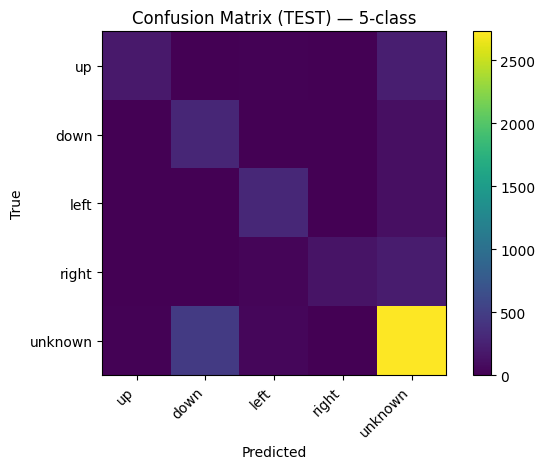

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/cnn_5class_weighted_1772453499_cm_test.png


In [22]:
test5_loss, test5_acc, y_true_test5, y_pred_test5 = eval5(model5, test5_loader)

cm_test5 = confusion_matrix_np(y_true_test5, y_pred_test5, n_classes=5)
macro_f1_test5, per_class_f1_test5 = macro_f1_from_cm(cm_test5)

print("TEST (5-class) accuracy:", test5_acc)
print("TEST (5-class) macro F1:", macro_f1_test5)
print("TEST per-class F1:", dict(zip(class_names_5, per_class_f1_test5.round(4))))

test5_cm_path = PROJECT_ROOT/"results/figures"/f"{cfg5.run_name}_cm_test.png"
plot_and_save_cm(cm_test5, class_names_5, "Confusion Matrix (TEST) — 5-class", test5_cm_path)

#### Save 5-class metrics to CSV

In [23]:
metrics_dir = PROJECT_ROOT/"results/metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

metrics5 = {
    "run_name": cfg5.run_name,
    "n_params": int(sum(p.numel() for p in model5.parameters() if p.requires_grad)),
    "best_val_acc": float(ckpt5.get("val_acc")),
    "val_acc": float(val5_acc),
    "val_macro_f1": float(macro_f1_val5),
    "test_acc": float(test5_acc),
    "test_macro_f1": float(macro_f1_test5),
}

metrics5_path = metrics_dir/f"{cfg5.run_name}_metrics.csv"
pd.DataFrame([metrics5]).to_csv(metrics5_path, index=False)

print("Saved metrics:", metrics5_path)
pd.DataFrame([metrics5])

Saved metrics: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/cnn_5class_weighted_1772453499_metrics.csv


,run_name,n_params,best_val_acc,val_acc,val_macro_f1,test_acc,test_macro_f1
0,cnn_5class_weighted_1772453499,23845,0.891019,0.891019,0.673565,0.74858,0.636543


## 6. Error analysis

#### Analyse 4-class modellen

In [24]:
import pandas as pd
import numpy as np

def error_analysis_from_cm(cm, class_names):
    results = []

    for i, true_class in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        row = cm[i].copy()
        row[i] = 0
        worst_pred = np.argmax(row)
        worst_count = row[worst_pred]

        results.append({
            "class": true_class,
            "recall": round(float(recall), 4),
            "most_confused_with": class_names[worst_pred],
            "confusion_count": int(worst_count)
        })

    return pd.DataFrame(results).sort_values("recall")

print("=== 4-class Error Analysis (TEST) ===")
error_4 = error_analysis_from_cm(cm_test, class_names_4)
error_4

=== 4-class Error Analysis (TEST) ===


,class,recall,most_confused_with,confusion_count
3,right,0.6439,left,75
2,left,0.8252,down,32
0,up,0.9176,down,30
1,down,0.9606,up,12


#### Top 5 misclassification pairs (4-class)

In [25]:
def top_confusions(cm, class_names, top_k=5):
    pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                pairs.append((
                    class_names[i],
                    class_names[j],
                    int(cm[i, j])
                ))
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    return pairs[:top_k]

print("Top 5 confusions (4-class TEST):")
top_confusions(cm_test, class_names_4, top_k=5)

Top 5 confusions (4-class TEST):


[('right', 'left', 75),
 ('right', 'down', 59),
 ('left', 'down', 32),
 ('up', 'down', 30),
 ('left', 'up', 26)]

#### Analyse 5-class modellen

In [26]:
print("=== 5-class Error Analysis (TEST) ===")
error_5 = error_analysis_from_cm(cm_test5, class_names_5)
error_5

=== 5-class Error Analysis (TEST) ===


,class,recall,most_confused_with,confusion_count
3,right,0.3636,unknown,209
0,up,0.4306,unknown,224
1,down,0.7192,unknown,110
2,left,0.7330,unknown,108
4,unknown,0.8397,down,463


In [27]:
unknown_id = class_names_5.index("unknown")

command_ids = [i for i, c in enumerate(class_names_5) if c != "unknown"]

unknown_confusions = {}

for cid in command_ids:
    unknown_confusions[class_names_5[cid]] = int(cm_test5[cid, unknown_id])

unknown_confusions

{'up': 224, 'down': 110, 'left': 108, 'right': 209}

In [28]:
false_commands = {}

for cid in command_ids:
    false_commands[class_names_5[cid]] = int(cm_test5[unknown_id, cid])

false_commands

{'up': 12, 'down': 463, 'left': 43, 'right': 3}

## 7. Latency & model size benchmarking

#### Utility functions (params, file size, timing)

In [29]:
import time
import os
import numpy as np
import torch

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

@torch.no_grad()
def benchmark_inference(model, sample_X, n_warmup=30, n_iters=200, device="cuda"):
    model = model.to(device)
    model.eval()
    X = sample_X.to(device)

    # Warmup (important on GPU)
    for _ in range(n_warmup):
        _ = model(X)

    if device == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(n_iters):
        _ = model(X)
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    avg_ms = (t1 - t0) * 1000.0 / n_iters
    return avg_ms

#### Load best checkpoints (4-class + 5-class)

In [30]:
ckpt4_path = PROJECT_ROOT/"models"/f"{cfg.run_name}_best.pt"
ckpt5_path = PROJECT_ROOT/"models"/f"{cfg5.run_name}_best.pt"

print("4-class ckpt:", ckpt4_path, "exists:", ckpt4_path.exists())
print("5-class ckpt:", ckpt5_path, "exists:", ckpt5_path.exists())

model4_bench = SmallSpectrogramCNN(n_classes=4)
model5_bench = SmallSpectrogramCNN(n_classes=5)

ckpt4 = torch.load(ckpt4_path, map_location="cpu")
ckpt5 = torch.load(ckpt5_path, map_location="cpu")

model4_bench.load_state_dict(ckpt4["model_state_dict"])
model5_bench.load_state_dict(ckpt5["model_state_dict"])

print("4-class params:", count_params(model4_bench))
print("5-class params:", count_params(model5_bench))
print("4-class ckpt size (MB):", round(file_size_mb(ckpt4_path), 3))
print("5-class ckpt size (MB):", round(file_size_mb(ckpt5_path), 3))

4-class ckpt: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_4class_baseline_1772452765_best.pt exists: True
5-class ckpt: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_5class_weighted_1772453499_best.pt exists: True
4-class params: 23780
5-class params: 23845
4-class ckpt size (MB): 0.1
5-class ckpt size (MB): 0.1


#### Get a single sample batch (shape [1,1,64,101])

In [31]:
X4, y4 = next(iter(test_loader))
X5, y5 = next(iter(test5_loader))

sample4 = X4[:1]
sample5 = X5[:1]

print("sample4 shape:", sample4.shape, "label:", y4[0].item())
print("sample5 shape:", sample5.shape, "label:", y5[0].item())

sample4 shape: torch.Size([1, 1, 64, 101]) label: 1
sample5 shape: torch.Size([1, 1, 64, 101]) label: 4


#### Benchmark GPU latency (if available)

In [32]:
has_cuda = torch.cuda.is_available()
print("CUDA available:", has_cuda)
if has_cuda:
    print("GPU:", torch.cuda.get_device_name(0))

results = []

if has_cuda:
    ms4_gpu = benchmark_inference(model4_bench, sample4, device="cuda")
    ms5_gpu = benchmark_inference(model5_bench, sample5, device="cuda")
    results.append(("4-class", "GPU", ms4_gpu))
    results.append(("5-class", "GPU", ms5_gpu))
    print("GPU latency (ms/sample):", results)
else:
    print("Skipping GPU benchmark (no CUDA).")

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU latency (ms/sample): [('4-class', 'GPU', 0.5533590150025702), ('5-class', 'GPU', 0.5588688500029093)]


#### Benchmark CPU latency

In [33]:
ms4_cpu = benchmark_inference(model4_bench, sample4, device="cpu")
ms5_cpu = benchmark_inference(model5_bench, sample5, device="cpu")

results.append(("4-class", "CPU", ms4_cpu))
results.append(("5-class", "CPU", ms5_cpu))

for r in results:
    print(f"{r[0]:7s} {r[1]:3s}  {r[2]:.3f} ms/sample")

4-class GPU  0.553 ms/sample
5-class GPU  0.559 ms/sample
4-class CPU  1.230 ms/sample
5-class CPU  1.203 ms/sample


#### Save benchmark results to CSV

In [34]:
import pandas as pd

bench_dir = PROJECT_ROOT/"results/metrics"
bench_dir.mkdir(parents=True, exist_ok=True)

rows = []
for model_name, dev, ms in results:
    rows.append({
        "run_name": cfg.run_name if model_name=="4-class" else cfg5.run_name,
        "model": model_name,
        "device": dev,
        "latency_ms_per_sample": float(ms),
    })

bench_df = pd.DataFrame(rows)
bench_path = bench_dir/"latency_benchmark.csv"
bench_df.to_csv(bench_path, index=False)

print("Saved:", bench_path)
bench_df

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/latency_benchmark.csv


,run_name,model,device,latency_ms_per_sample
0,cnn_4class_baseline_1772452765,4-class,GPU,0.553359
1,cnn_5class_weighted_1772453499,5-class,GPU,0.558869
2,cnn_4class_baseline_1772452765,4-class,CPU,1.230130
3,cnn_5class_weighted_1772453499,5-class,CPU,1.202805
